<a href="https://colab.research.google.com/github/26b21a4274kiet0-dev/Loan-payment-matrix-model-/blob/main/LOAN_PAYMENT_MATRIX_MODEL_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



             LOAN PAYMENT MATRIX MODEL


--------------------------------------------------------------------------------
Home Loan
--------------------------------------------------------------------------------
Principal Amount : ₹500,000.00
Annual Interest  : 8.50%
Loan Term        : 60 months
Monthly EMI      : ₹10,258.27

Transition Matrix A:
[[ 1.00708333e+00 -1.02582657e+04]
 [ 0.00000000e+00  1.00000000e+00]]

Cayley-Hamilton A^60:
[[ 1.52730060e+00 -7.63650299e+05]
 [ 0.00000000e+00  1.00000000e+00]]

Eigenvalues:
λ = 1.007083
λ = 1.000000

Cayley-Hamilton Verification:
Matrix([[2.22044604925031e-16, -3.63797880709171e-12], [0, 2.22044604925031e-16]])
✗ Verification failed.

Balance after 60 months : ₹0.00
Total Interest Paid    : ₹115,495.94
Total Amount Paid      : ₹615,495.94
Loan Paid Off At       : Month 60


--------------------------------------------------------------------------------
Education Loan
-------------------------------------------------------------------

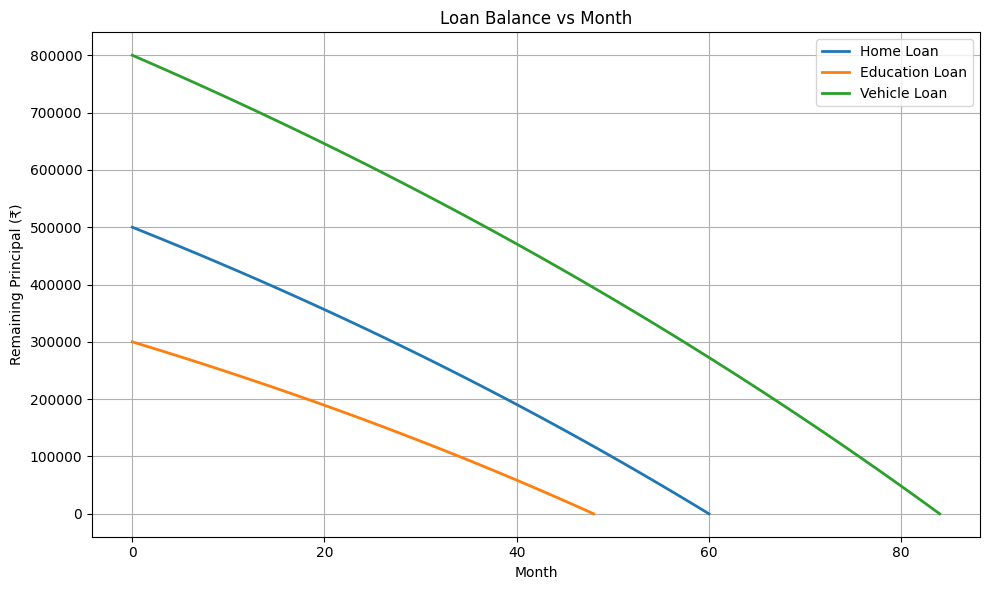

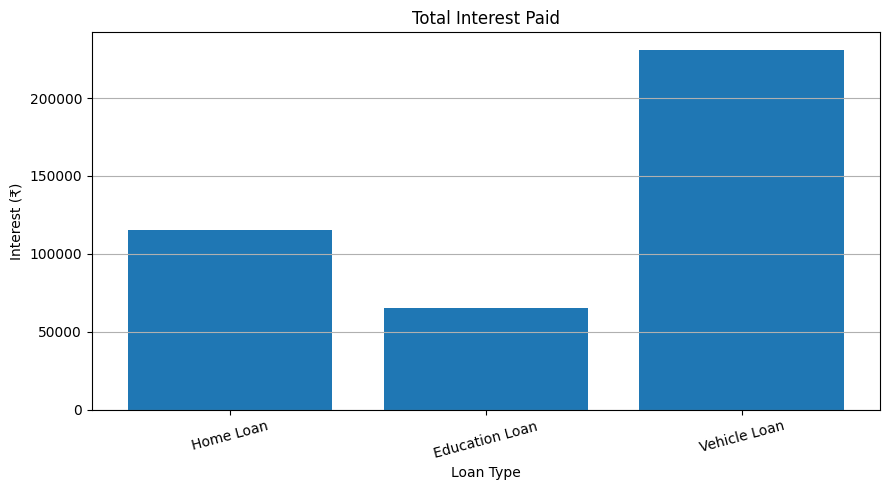

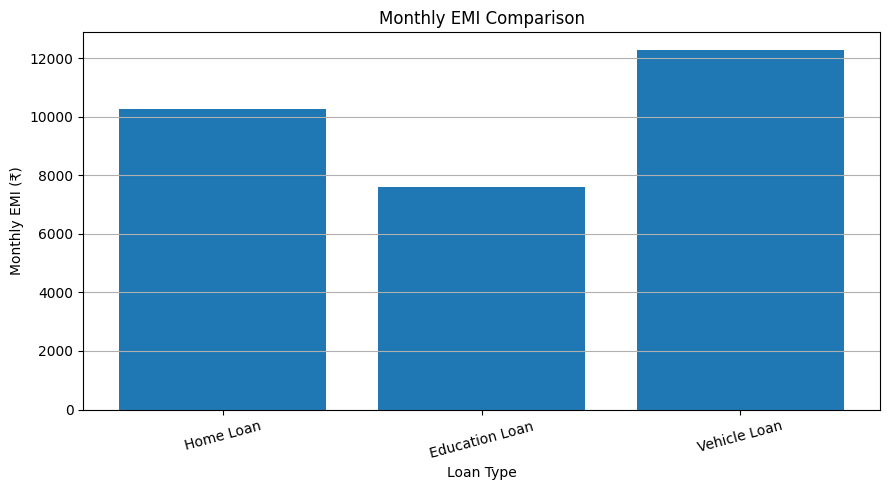



                         CONCLUSION

This project models loan repayment using matrices.

The main mathematical model is:

        [ P(n+1) ]   [ 1+r   -EMI ] [ P(n) ]
        [    1   ] = [  0      1  ] [  1  ]

The Cayley-Hamilton theorem is used to calculate
high powers of the transition matrix, including A^60.

Eigenvalues are obtained from the transition matrix
to study its mathematical behavior.

The program also calculates:

1. Monthly EMI
2. Transition matrix A
3. A^60
4. Eigenvalues
5. Remaining principal
6. Total interest paid
7. Loan payoff month
8. Graphs for loan comparison

This connects B.Tech matrix theory with a
real-world loan repayment application.

                 PROJECT COMPLETED


In [1]:
# ============================================================
# LOAN PAYMENT MATRIX MODEL (F7)
# B.Tech Mathematics Mini Project
# ============================================================
#
# Concepts:
# 1. EMI calculation
# 2. Transition matrix
# 3. Cayley-Hamilton theorem
# 4. Matrix power A^60
# 5. Eigenvalues
# 6. Loan balance / payoff month
# 7. Total interest
# 8. Charts
#
# Environment: Google Colab
# Libraries: NumPy, SymPy, Matplotlib
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt


# ============================================================
# 2. USER INPUT
# ============================================================
#
# Change these values for your own project.
#
# Principal = Loan amount
# Annual rate = Interest rate per year
# Term = Loan duration in months
#
# We use 3 realistic benchmark loans.
# ============================================================

loans = [
    {
        "name": "Home Loan",
        "principal": 500000,
        "annual_rate": 8.5,
        "term": 60
    },

    {
        "name": "Education Loan",
        "principal": 300000,
        "annual_rate": 10.0,
        "term": 48
    },

    {
        "name": "Vehicle Loan",
        "principal": 800000,
        "annual_rate": 7.5,
        "term": 84
    }
]

TARGET_MONTH = 60


# ============================================================
# 3. EMI CALCULATION
# ============================================================

def calculate_emi(principal, annual_rate, months):

    monthly_rate = annual_rate / (12 * 100)

    # Zero-interest case
    if monthly_rate == 0:
        return principal / months

    emi = (
        principal
        * monthly_rate
        * (1 + monthly_rate) ** months
        / ((1 + monthly_rate) ** months - 1)
    )

    return emi


# ============================================================
# 4. TRANSITION MATRIX
# ============================================================
#
# Loan balance equation:
#
# P(n+1) = (1+r)P(n) - EMI
#
# To represent this using a matrix:
#
# [ P(n+1) ]   [ 1+r   -EMI ] [ P(n) ]
# [    1   ] = [  0      1  ] [  1  ]
#
# Therefore:
#
#             [1+r   -EMI]
# A =         [ 0       1 ]
#
# ============================================================

def create_matrix(annual_rate, emi):

    r = annual_rate / (12 * 100)

    A = sp.Matrix([
        [1 + r, -emi],
        [0, 1]
    ])

    return A


# ============================================================
# 5. CAYLEY-HAMILTON MATRIX POWER
# ============================================================
#
# Cayley-Hamilton theorem:
#
# A² - tr(A)A + det(A)I = 0
#
# Therefore:
#
# A^n = tr(A)A^(n-1) - det(A)A^(n-2)
#
# We use this recurrence to calculate A^60.
# ============================================================

def matrix_power_CH(A, n):

    if n == 0:
        return sp.eye(2)

    if n == 1:
        return A

    trace_A = sp.trace(A)
    determinant_A = A.det()

    previous2 = sp.eye(2)
    previous1 = A

    for k in range(2, n + 1):

        current = (
            trace_A * previous1
            - determinant_A * previous2
        )

        previous2 = previous1
        previous1 = current

    return sp.simplify(previous1)


# ============================================================
# 6. LOAN CALCULATION
# ============================================================

results = []


for loan in loans:

    name = loan["name"]
    principal = loan["principal"]
    annual_rate = loan["annual_rate"]
    term = loan["term"]

    # --------------------------------------------------------
    # EMI
    # --------------------------------------------------------

    emi = calculate_emi(
        principal,
        annual_rate,
        term
    )

    # --------------------------------------------------------
    # Transition Matrix
    # --------------------------------------------------------

    A = create_matrix(
        annual_rate,
        emi
    )

    # --------------------------------------------------------
    # A^60 using Cayley-Hamilton
    # --------------------------------------------------------

    A60 = matrix_power_CH(
        A,
        TARGET_MONTH
    )

    # --------------------------------------------------------
    # Eigenvalues
    # --------------------------------------------------------

    eigenvalues = A.eigenvals()

    # --------------------------------------------------------
    # Verify Cayley-Hamilton theorem
    # --------------------------------------------------------

    trace_A = A.trace()
    determinant_A = A.det()
    I = sp.eye(2)

    CH_check = sp.simplify(
        A**2
        - trace_A * A
        + determinant_A * I
    )

    # --------------------------------------------------------
    # Monthly loan simulation
    # --------------------------------------------------------

    monthly_rate = annual_rate / (12 * 100)

    balance = principal

    balances = [balance]

    interest_paid = 0

    payments = 0

    payoff_month = None

    for month in range(1, term + 1):

        interest = balance * monthly_rate

        principal_payment = emi - interest

        interest_paid += interest

        balance = balance - principal_payment

        # Prevent tiny floating-point negative values
        if balance < 0:
            balance = 0

        balances.append(balance)

        payments += 1

        if balance <= 0.01:

            payoff_month = month

            break

    # --------------------------------------------------------
    # Balance after 60 months
    # --------------------------------------------------------

    if TARGET_MONTH < len(balances):

        balance_60 = balances[TARGET_MONTH]

    else:

        balance_60 = 0

    # --------------------------------------------------------
    # Total amount paid
    # --------------------------------------------------------

    total_paid = emi * payments

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append({

        "name": name,

        "principal": principal,

        "annual_rate": annual_rate,

        "term": term,

        "emi": emi,

        "matrix": A,

        "A60": A60,

        "eigenvalues": eigenvalues,

        "balances": balances,

        "interest": interest_paid,

        "total_paid": total_paid,

        "payoff_month": payoff_month,

        "balance_60": balance_60,

        "CH_check": CH_check
    })


# ============================================================
# 7. DISPLAY RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("             LOAN PAYMENT MATRIX MODEL")
print("=" * 80)


for result in results:

    print("\n")
    print("-" * 80)

    print(result["name"])

    print("-" * 80)

    print(
        f"Principal Amount : ₹{result['principal']:,.2f}"
    )

    print(
        f"Annual Interest  : {result['annual_rate']:.2f}%"
    )

    print(
        f"Loan Term        : {result['term']} months"
    )

    print(
        f"Monthly EMI      : ₹{result['emi']:,.2f}"
    )

    print("\nTransition Matrix A:")

    print(
        np.array(
            result["matrix"]
        ).astype(float)
    )

    print("\nCayley-Hamilton A^60:")

    print(
        np.array(
            result["A60"]
        ).astype(float)
    )

    print("\nEigenvalues:")

    for eigenvalue in result["eigenvalues"]:

        print(
            f"λ = {float(sp.N(eigenvalue)):.6f}"
        )

    print("\nCayley-Hamilton Verification:")

    print(result["CH_check"])

    if result["CH_check"] == sp.zeros(2):

        print("✓ Cayley-Hamilton theorem verified.")

    else:

        print("✗ Verification failed.")

    print(
        f"\nBalance after 60 months : "
        f"₹{result['balance_60']:,.2f}"
    )

    print(
        f"Total Interest Paid    : "
        f"₹{result['interest']:,.2f}"
    )

    print(
        f"Total Amount Paid      : "
        f"₹{result['total_paid']:,.2f}"
    )

    print(
        f"Loan Paid Off At       : "
        f"Month {result['payoff_month']}"
    )


# ============================================================
# 8. SUMMARY TABLE
# ============================================================

print("\n")
print("=" * 100)
print("                         SUMMARY")
print("=" * 100)

print(
    f"{'Loan':<20}"
    f"{'EMI':>15}"
    f"{'Interest':>18}"
    f"{'Balance @ 60':>18}"
    f"{'Payoff Month':>15}"
)

print("-" * 100)

for result in results:

    print(
        f"{result['name']:<20}"
        f"₹{result['emi']:>13,.2f}"
        f"₹{result['interest']:>16,.2f}"
        f"₹{result['balance_60']:>16,.2f}"
        f"{result['payoff_month']:>15}"
    )


# ============================================================
# 9. CHART 1 - LOAN BALANCE VS MONTH
# ============================================================

plt.figure(figsize=(10, 6))

for result in results:

    months = range(
        len(result["balances"])
    )

    plt.plot(
        months,
        result["balances"],
        linewidth=2,
        label=result["name"]
    )

plt.title(
    "Loan Balance vs Month"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Remaining Principal (₹)"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 10. CHART 2 - TOTAL INTEREST
# ============================================================

names = [
    result["name"]
    for result in results
]

interest_values = [
    result["interest"]
    for result in results
]

plt.figure(figsize=(9, 5))

plt.bar(
    names,
    interest_values
)

plt.title(
    "Total Interest Paid"
)

plt.xlabel(
    "Loan Type"
)

plt.ylabel(
    "Interest (₹)"
)

plt.xticks(
    rotation=15
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()


# ============================================================
# 11. CHART 3 - EMI COMPARISON
# ============================================================

emi_values = [
    result["emi"]
    for result in results
]

plt.figure(figsize=(9, 5))

plt.bar(
    names,
    emi_values
)

plt.title(
    "Monthly EMI Comparison"
)

plt.xlabel(
    "Loan Type"
)

plt.ylabel(
    "Monthly EMI (₹)"
)

plt.xticks(
    rotation=15
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()


# ============================================================
# 12. FINAL PROJECT CONCLUSION
# ============================================================

print("\n")
print("=" * 80)
print("                         CONCLUSION")
print("=" * 80)

print("""
This project models loan repayment using matrices.

The main mathematical model is:

        [ P(n+1) ]   [ 1+r   -EMI ] [ P(n) ]
        [    1   ] = [  0      1  ] [  1  ]

The Cayley-Hamilton theorem is used to calculate
high powers of the transition matrix, including A^60.

Eigenvalues are obtained from the transition matrix
to study its mathematical behavior.

The program also calculates:

1. Monthly EMI
2. Transition matrix A
3. A^60
4. Eigenvalues
5. Remaining principal
6. Total interest paid
7. Loan payoff month
8. Graphs for loan comparison

This connects B.Tech matrix theory with a
real-world loan repayment application.
""")

print("=" * 80)
print("                 PROJECT COMPLETED")
print("=" * 80)